# Phase 4 — Error Analysis

**Sentiment140 — Understanding Model Failures**

This notebook investigates *why* the best-performing model (Linear SVC, F1 = 0.78) makes mistakes.
Rather than just reporting aggregate metrics, we dig into the individual errors to surface
linguistic patterns, edge cases, and structural weaknesses.

**Participants:** Noam Kadosh · Roy Boker · Gal Tayeb · Noam Dahan

---
### Analysis Plan
1. Reproduce the best model pipeline and collect errors on the test set
2. Confusion matrix deep-dive (False Positives vs False Negatives)
3. High-confidence errors — cases the model was *certain* but wrong
4. Error word analysis — which words drive mistakes?
5. Tweet length vs error rate
6. Linguistic patterns — sarcasm, negation, slang
7. Conclusions — model limitations and suggested improvements

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'matplotlib', 'seaborn', 'wordcloud', 'nltk', 'scikit-learn'])
print('Dependencies ready.')

Dependencies ready.


In [2]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, f1_score, accuracy_score)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

STOP_WORDS  = set(stopwords.words('english'))
LEMMATIZER  = WordNetLemmatizer()
COLOR_POS   = '#2ecc71'
COLOR_NEG   = '#e74c3c'
COLOR_FP    = '#f39c12'   # False Positive
COLOR_FN    = '#9b59b6'   # False Negative
print('Imports ready.')

Imports ready.


---
## 1. Data Preparation & Model Training

In [3]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full = pd.read_csv('../data-sets/training.1600000.processed.noemoticon.csv',
                      encoding='latin-1', header=None, names=columns)

SAMPLE_PER_CLASS = 100_000
df = pd.concat([
    df_full[df_full['sentiment'] == 0].sample(SAMPLE_PER_CLASS, random_state=42),
    df_full[df_full['sentiment'] == 4].sample(SAMPLE_PER_CLASS, random_state=42),
]).reset_index(drop=True)
df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})
print(f'Sample: {len(df):,} tweets  ({SAMPLE_PER_CLASS:,} per class)')

Sample: 200,000 tweets  (100,000 per class)


In [4]:
def preprocess_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^rt\s+', '', text)
    text = re.sub(r'&\w+;', '', text)
    text = text.replace('#', '')
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess_tweet)
print('Preprocessing done.')

Preprocessing done.


In [5]:
tfidf   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X       = tfidf.fit_transform(df['text_clean'])
y       = df['sentiment'].map({0: 0, 4: 1}).values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, stratify=y, random_state=42)

model = LinearSVC(C=1.0, max_iter=2000)
model.fit(X_train, y_train)

y_pred   = model.predict(X_test)
scores   = model.decision_function(X_test)

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test F1       : {f1_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Test Accuracy : 0.7681
Test F1       : 0.7728
              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76     20000
    Positive       0.76      0.79      0.77     20000

    accuracy                           0.77     40000
   macro avg       0.77      0.77      0.77     40000
weighted avg       0.77      0.77      0.77     40000



In [6]:
# Build a test-set DataFrame with predictions and confidence
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

test_df = df.loc[idx_test].copy().reset_index(drop=True)
test_df['y_true']      = y_test
test_df['y_pred']      = y_pred
test_df['raw_score']   = scores
test_df['confidence']  = sigmoid(np.abs(scores))
test_df['correct']     = test_df['y_true'] == test_df['y_pred']
test_df['error_type']  = 'Correct'
test_df.loc[(test_df['y_true'] == 0) & (test_df['y_pred'] == 1), 'error_type'] = 'False Positive'
test_df.loc[(test_df['y_true'] == 1) & (test_df['y_pred'] == 0), 'error_type'] = 'False Negative'

errors_df = test_df[~test_df['correct']].copy()
fp_df     = test_df[test_df['error_type'] == 'False Positive']
fn_df     = test_df[test_df['error_type'] == 'False Negative']

print(f'Total test samples : {len(test_df):,}')
print(f'Total errors       : {len(errors_df):,}  ({len(errors_df)/len(test_df)*100:.1f}%)')
print(f'  False Positives  : {len(fp_df):,}  — predicted Positive, actually Negative')
print(f'  False Negatives  : {len(fn_df):,}  — predicted Negative, actually Positive')

Total test samples : 40,000
Total errors       : 9,274  (23.2%)
  False Positives  : 5,048  — predicted Positive, actually Negative
  False Negatives  : 4,226  — predicted Negative, actually Positive


---
## 2. Confusion Matrix Deep-Dive

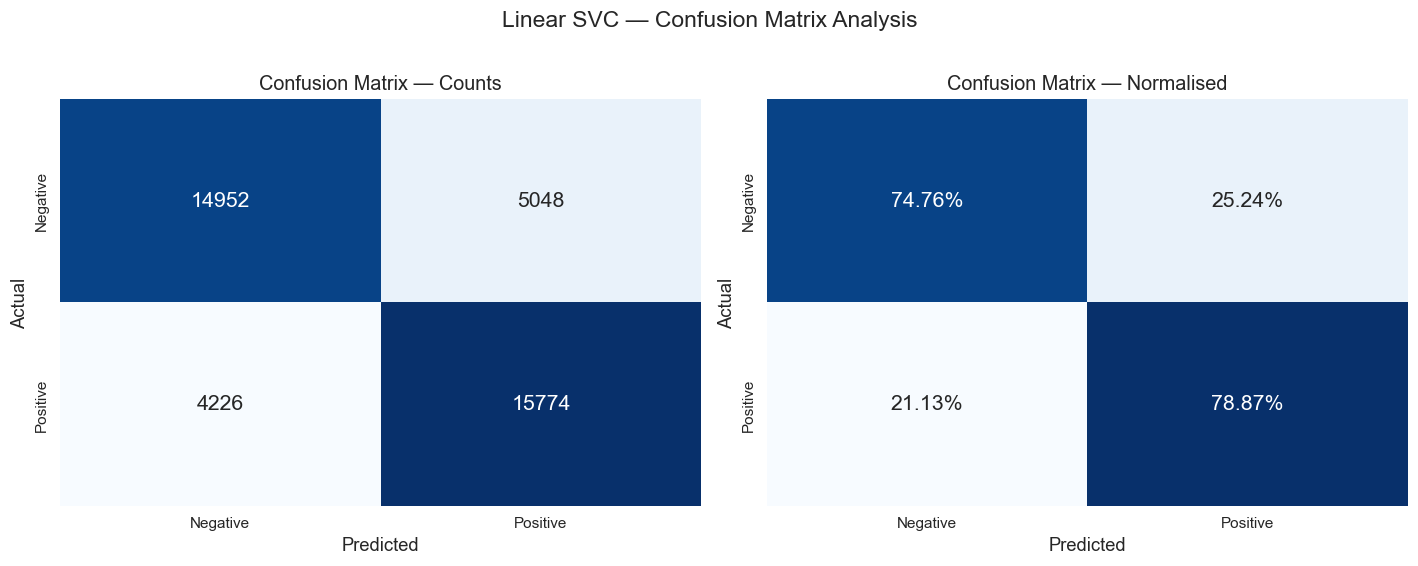

True  Negatives : 14,952   (correctly predicted Negative)
True  Positives : 15,774   (correctly predicted Positive)
False Positives : 5,048   (predicted Positive — was actually Negative)
False Negatives : 4,226   (predicted Negative — was actually Positive)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Standard confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0],
            annot_kws={'size': 14})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix — Counts', fontsize=13)

# Normalised confusion matrix (percentages)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[1],
            annot_kws={'size': 14})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix — Normalised', fontsize=13)

plt.suptitle('Linear SVC — Confusion Matrix Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives : {tn:,}   (correctly predicted Negative)')
print(f'True  Positives : {tp:,}   (correctly predicted Positive)')
print(f'False Positives : {fp:,}   (predicted Positive — was actually Negative)')
print(f'False Negatives : {fn:,}   (predicted Negative — was actually Positive)')

---
## 3. High-Confidence Errors

These are the most dangerous errors — tweets where the model was **very confident** but completely wrong.
They reveal systematic blind spots rather than borderline cases.

In [8]:
top_fp = fp_df.nlargest(10, 'confidence')[['text', 'confidence']].reset_index(drop=True)
top_fn = fn_df.nlargest(10, 'confidence')[['text', 'confidence']].reset_index(drop=True)

print('=== TOP 10 FALSE POSITIVES ===')
print('(Model predicted POSITIVE with high confidence — actually NEGATIVE)\n')
for i, row in top_fp.iterrows():
    print(f'[{i+1}] Confidence: {row["confidence"]*100:.1f}%')
    print(f'     {row["text"][:120]}')
    print()

print('\n=== TOP 10 FALSE NEGATIVES ===')
print('(Model predicted NEGATIVE with high confidence — actually POSITIVE)\n')
for i, row in top_fn.iterrows():
    print(f'[{i+1}] Confidence: {row["confidence"]*100:.1f}%')
    print(f'     {row["text"][:120]}')
    print()

=== TOP 10 FALSE POSITIVES ===
(Model predicted POSITIVE with high confidence — actually NEGATIVE)

[1] Confidence: 83.9%
     @jay_f_k thank u 

[2] Confidence: 82.4%
     Welcome to all the new followers of cpapsupplyusa.  Hope you had a great weekend.  It's raining here now  , have a great

[3] Confidence: 81.5%
     @TiaMowry that is beautiful!  very happy for u!!

[4] Confidence: 80.7%
     @anthonyamor hey member when we were better friends then you and anthony. That was pretty sweet ha. Way to be a trader f

[5] Confidence: 80.3%
     [stapler haiku] Whar a Night! Woo Hoo! Yeah! / A beautiful night to party! / Oops, I'm a stapler...  

[6] Confidence: 80.3%
     [stapler haiku] Whar a Night! Woo Hoo! Yeah! / A beautiful night to party! / Oops, I'm a stapler...  

[7] Confidence: 79.9%
     love the jonas brothers new album! Especially the song &quot;much better&quot; where Joe Jonas bashes Taylor Swift! 

[8] Confidence: 79.6%
     @AIPChristina Thanks 

[9] Confidence: 79.6%
  

---
## 4. Error Word Analysis

Which words appear most frequently in misclassified tweets?
We compare word frequencies in errors vs. correct predictions to find the most *confusing* vocabulary.

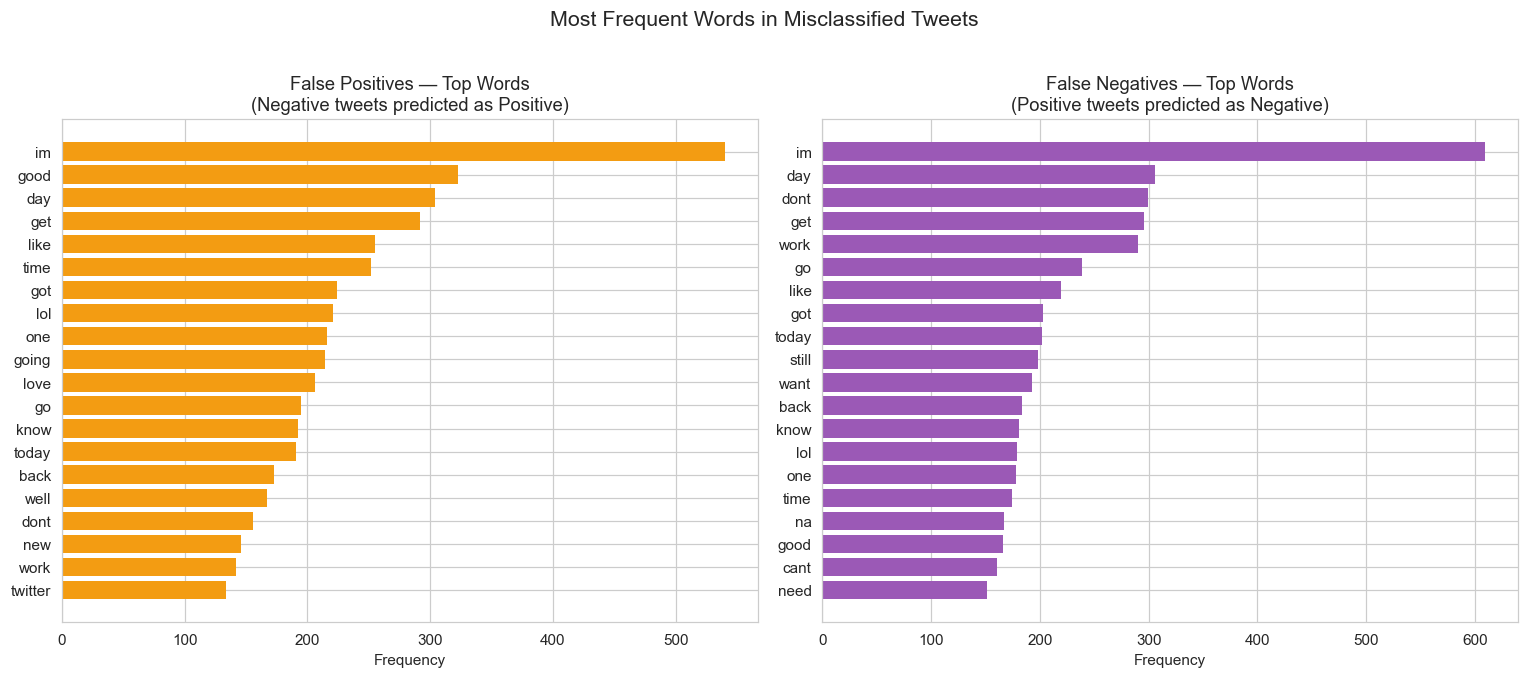

In [9]:
def top_words(series, n=30):
    words = []
    for t in series.dropna():
        words.extend(str(t).split())
    return Counter(words).most_common(n)

fp_words = dict(top_words(fp_df['text_clean'], 40))
fn_words = dict(top_words(fn_df['text_clean'], 40))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# False Positives — top words
fp_top = sorted(fp_words.items(), key=lambda x: x[1], reverse=True)[:20]
words_fp, counts_fp = zip(*fp_top)
axes[0].barh(list(reversed(words_fp)), list(reversed(counts_fp)),
             color=COLOR_FP, edgecolor='none')
axes[0].set_title('False Positives — Top Words\n(Negative tweets predicted as Positive)',
                  fontsize=12)
axes[0].set_xlabel('Frequency')

# False Negatives — top words
fn_top = sorted(fn_words.items(), key=lambda x: x[1], reverse=True)[:20]
words_fn, counts_fn = zip(*fn_top)
axes[1].barh(list(reversed(words_fn)), list(reversed(counts_fn)),
             color=COLOR_FN, edgecolor='none')
axes[1].set_title('False Negatives — Top Words\n(Positive tweets predicted as Negative)',
                  fontsize=12)
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words in Misclassified Tweets', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

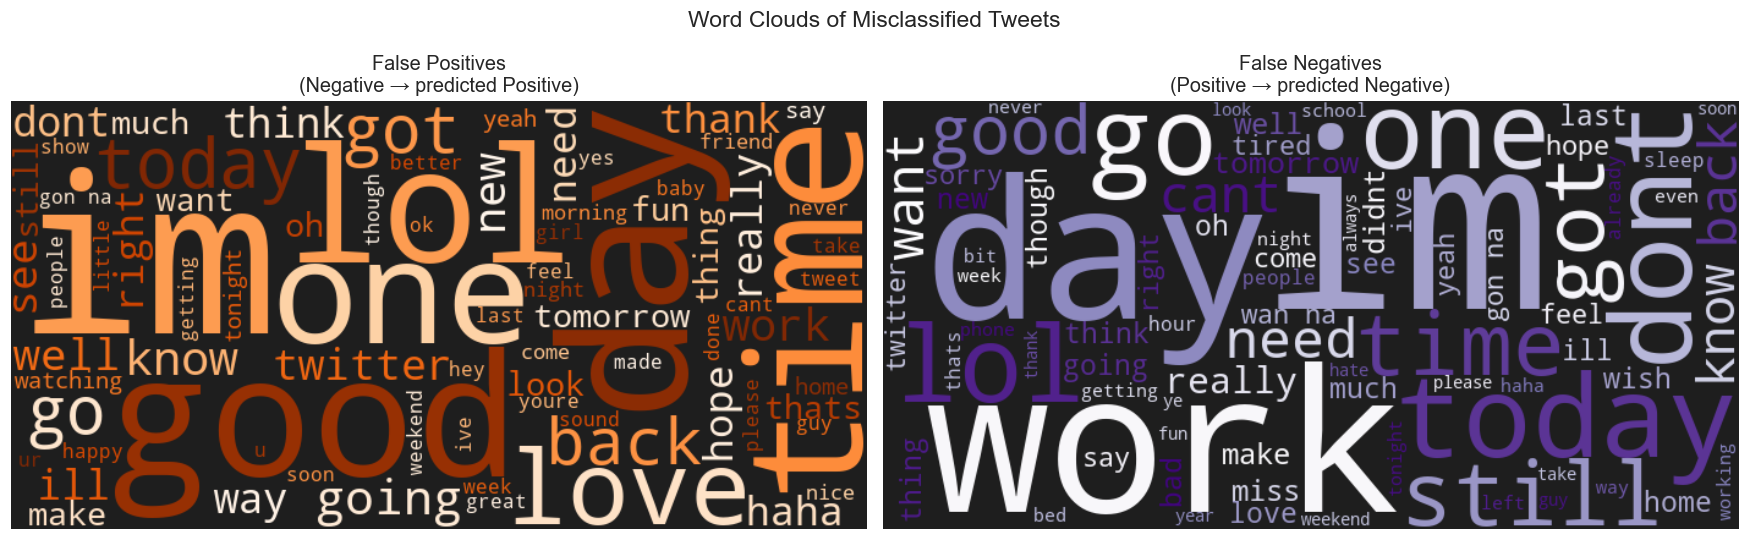

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sub_df, title, color in [
    (axes[0], fp_df,  'False Positives\n(Negative → predicted Positive)', COLOR_FP),
    (axes[1], fn_df,  'False Negatives\n(Positive → predicted Negative)', COLOR_FN),
]:
    text = ' '.join(sub_df['text_clean'].dropna().astype(str))
    wc = WordCloud(width=700, height=350, background_color='#1e1e1e',
                   max_words=80, colormap='Oranges' if color == COLOR_FP else 'Purples',
                   prefer_horizontal=0.9).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.suptitle('Word Clouds of Misclassified Tweets', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

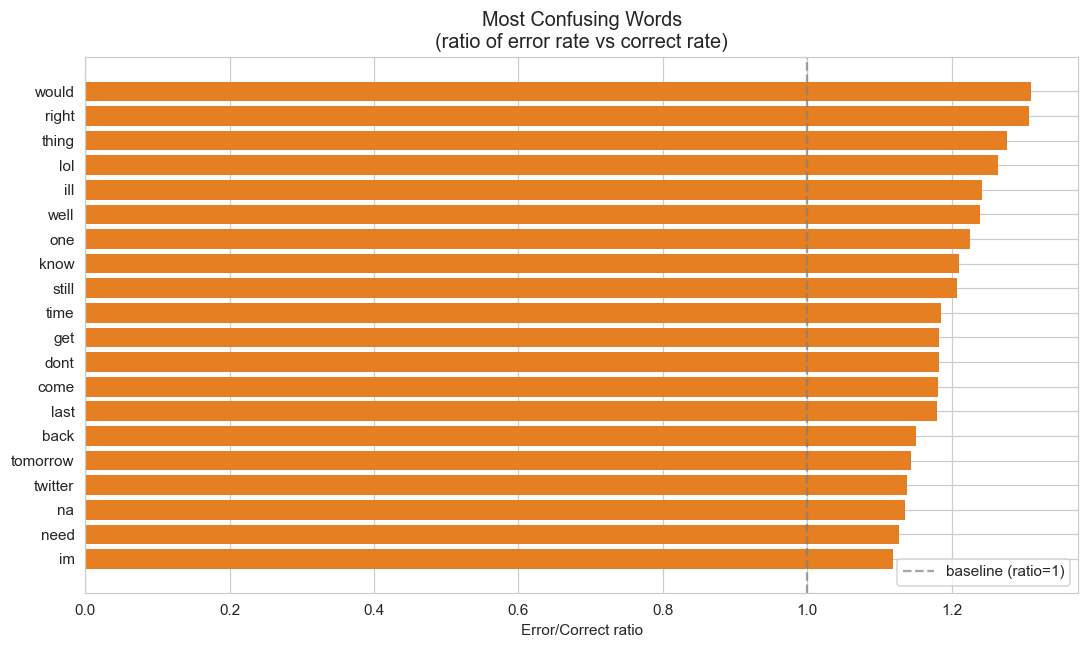

Top 10 most confusing words:
  would                 confusion ratio: 1.31x
  right                 confusion ratio: 1.31x
  thing                 confusion ratio: 1.28x
  lol                   confusion ratio: 1.26x
  ill                   confusion ratio: 1.24x
  well                  confusion ratio: 1.24x
  one                   confusion ratio: 1.23x
  know                  confusion ratio: 1.21x
  still                 confusion ratio: 1.21x
  time                  confusion ratio: 1.19x


In [11]:
# Words that cause the most confusion — appear heavily in BOTH error types
all_error_words = dict(top_words(errors_df['text_clean'], 60))
correct_words   = dict(top_words(test_df[test_df['correct']]['text_clean'], 60))

# Confusion ratio: how much more a word appears in errors vs correct predictions
n_errors  = len(errors_df)
n_correct = len(test_df) - n_errors

confusion_scores = {}
for w in set(all_error_words) | set(correct_words):
    err_rate  = all_error_words.get(w, 0) / max(n_errors, 1)
    corr_rate = correct_words.get(w, 0)  / max(n_correct, 1)
    if corr_rate > 0:
        confusion_scores[w] = err_rate / corr_rate

top_confusing = sorted(confusion_scores.items(), key=lambda x: x[1], reverse=True)[:20]
words_c, scores_c = zip(*top_confusing)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(reversed(words_c)), list(reversed(scores_c)),
        color='#e67e22', edgecolor='none')
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.7, label='baseline (ratio=1)')
ax.set_title('Most Confusing Words\n(ratio of error rate vs correct rate)', fontsize=13)
ax.set_xlabel('Error/Correct ratio')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 most confusing words:')
for w, s in top_confusing[:10]:
    print(f'  {w:20s}  confusion ratio: {s:.2f}x')

---
## 5. Tweet Length vs Error Rate

Do shorter or longer tweets confuse the model more?

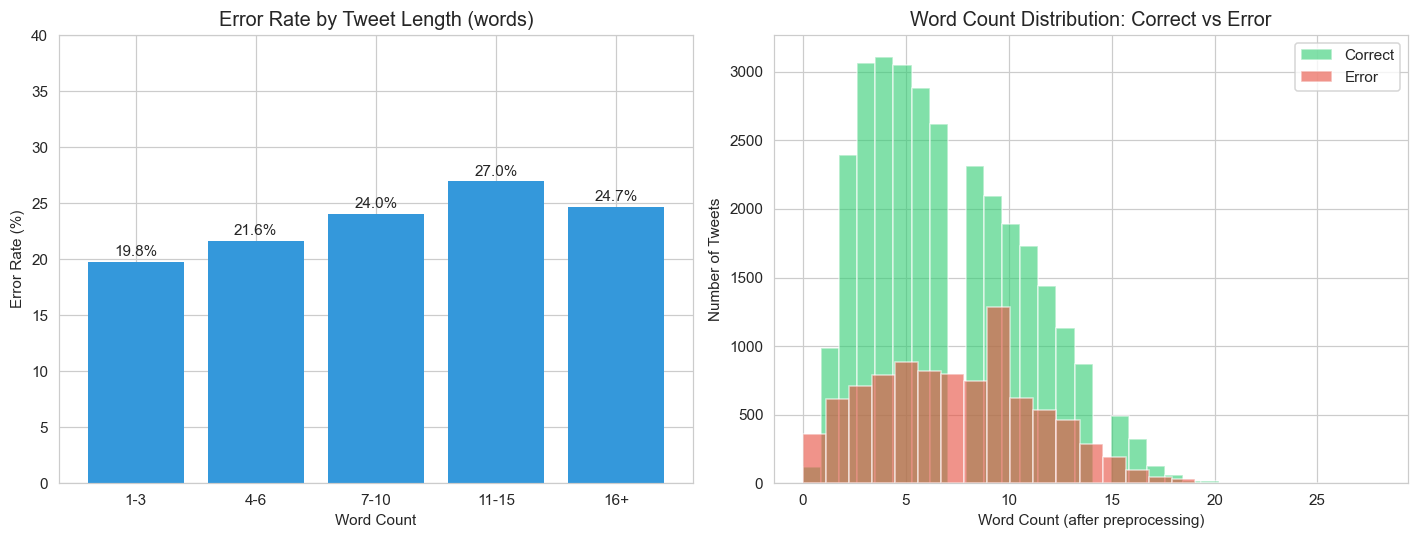

            total  errors  error_rate
length_bin                           
1-3          8035    1590   19.788426
4-6         11543    2498   21.640821
7-10        11743    2824   24.048369
11-15        7748    2089   26.961797
16+           721     178   24.687933


In [12]:
test_df['word_count'] = test_df['text_clean'].apply(lambda x: len(str(x).split()))
test_df['length_bin'] = pd.cut(test_df['word_count'],
                                bins=[0, 3, 6, 10, 15, 100],
                                labels=['1-3', '4-6', '7-10', '11-15', '16+'])

error_rate_by_len = test_df.groupby('length_bin', observed=True).agg(
    total=('correct', 'count'),
    errors=('correct', lambda x: (~x).sum())
).assign(error_rate=lambda d: d['errors'] / d['total'] * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Error rate by length
axes[0].bar(error_rate_by_len.index, error_rate_by_len['error_rate'],
            color='#3498db', edgecolor='none')
axes[0].set_title('Error Rate by Tweet Length (words)', fontsize=13)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Error Rate (%)')
axes[0].set_ylim(0, 40)
for i, (_, row) in enumerate(error_rate_by_len.iterrows()):
    axes[0].text(i, row['error_rate'] + 0.5, f"{row['error_rate']:.1f}%",
                 ha='center', fontsize=10)

# Distribution of word counts in errors vs correct
test_df[test_df['correct']]['word_count'].hist(
    bins=25, ax=axes[1], alpha=0.6, color=COLOR_POS, label='Correct')
test_df[~test_df['correct']]['word_count'].hist(
    bins=25, ax=axes[1], alpha=0.6, color=COLOR_NEG, label='Error')
axes[1].set_title('Word Count Distribution: Correct vs Error', fontsize=13)
axes[1].set_xlabel('Word Count (after preprocessing)')
axes[1].set_ylabel('Number of Tweets')
axes[1].legend()

plt.tight_layout()
plt.show()
print(error_rate_by_len[['total', 'errors', 'error_rate']].to_string())

---
## 6. Linguistic Patterns in Errors

We identify three classic NLP failure modes:
- **Negation** — "I do NOT love this"
- **Sarcasm/Irony** — "Oh great, another Monday"
- **Slang** — "This is sick!" (positive meaning)

In [13]:
negation_words = ['not', "n't", 'no', 'never', 'neither', "don't", "doesn't",
                  "didn't", "can't", "won't", "isn't", "wasn't"]
sarcasm_phrases = ['oh great', 'just great', 'wonderful', 'fantastic', 'love it',
                   'thanks a lot', 'lovely', 'brilliant']
slang_positive  = ['sick', 'crazy', 'insane', 'wicked', 'savage', 'beast', 'fire',
                   'lit', 'goat', 'dope', 'killer']

def contains_any(text, patterns):
    t = str(text).lower()
    return any(p in t for p in patterns)

# Check patterns in raw text
for label, df_sub, color in [
    ('False Positives', fp_df, COLOR_FP),
    ('False Negatives', fn_df, COLOR_FN),
]:
    neg_rate   = df_sub['text'].apply(lambda t: contains_any(t, negation_words)).mean()
    sarc_rate  = df_sub['text'].apply(lambda t: contains_any(t, sarcasm_phrases)).mean()
    slang_rate = df_sub['text'].apply(lambda t: contains_any(t, slang_positive)).mean()
    print(f'--- {label} ---')
    print(f'  Negation words present : {neg_rate*100:.1f}%')
    print(f'  Sarcasm phrases present: {sarc_rate*100:.1f}%')
    print(f'  Positive slang present : {slang_rate*100:.1f}%')
    print()

--- False Positives ---
  Negation words present : 38.3%
  Sarcasm phrases present: 0.9%
  Positive slang present : 3.4%

--- False Negatives ---
  Negation words present : 38.4%
  Sarcasm phrases present: 0.7%
  Positive slang present : 3.4%



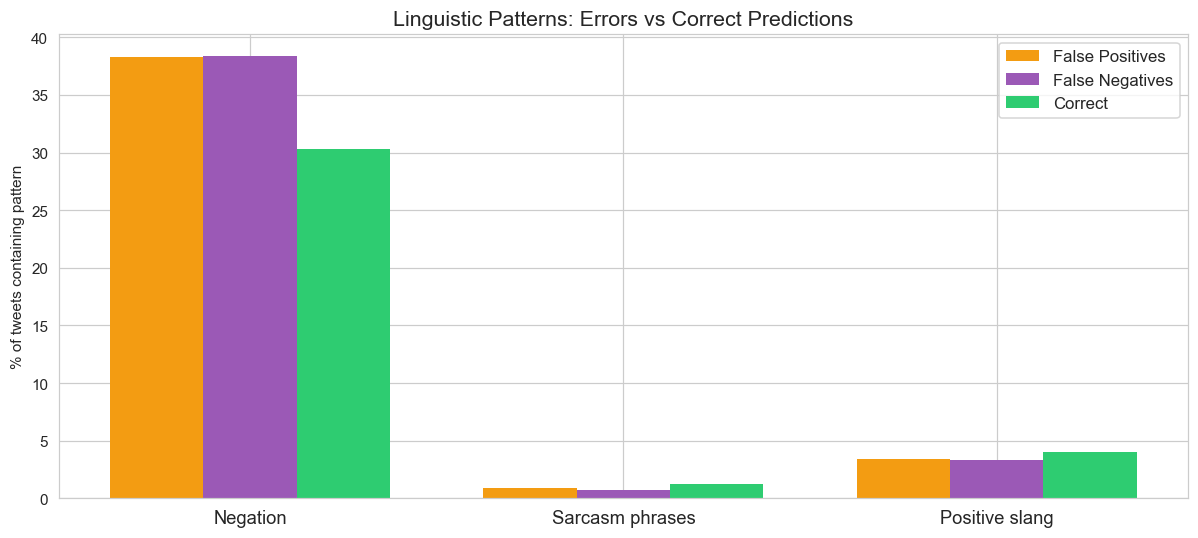

In [14]:
categories   = ['Negation', 'Sarcasm phrases', 'Positive slang']
patterns_map = [negation_words, sarcasm_phrases, slang_positive]

fp_rates   = [fp_df['text'].apply(lambda t: contains_any(t, p)).mean() * 100 for p in patterns_map]
fn_rates   = [fn_df['text'].apply(lambda t: contains_any(t, p)).mean() * 100 for p in patterns_map]
corr_rates = [test_df[test_df['correct']]['text'].apply(
                  lambda t: contains_any(t, p)).mean() * 100 for p in patterns_map]

x = np.arange(len(categories))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, fp_rates,   w, label='False Positives',  color=COLOR_FP,  edgecolor='none')
ax.bar(x,     fn_rates,   w, label='False Negatives',  color=COLOR_FN,  edgecolor='none')
ax.bar(x + w, corr_rates, w, label='Correct',          color='#2ecc71', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('% of tweets containing pattern')
ax.set_title('Linguistic Patterns: Errors vs Correct Predictions', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Confidence Distribution — Errors vs Correct

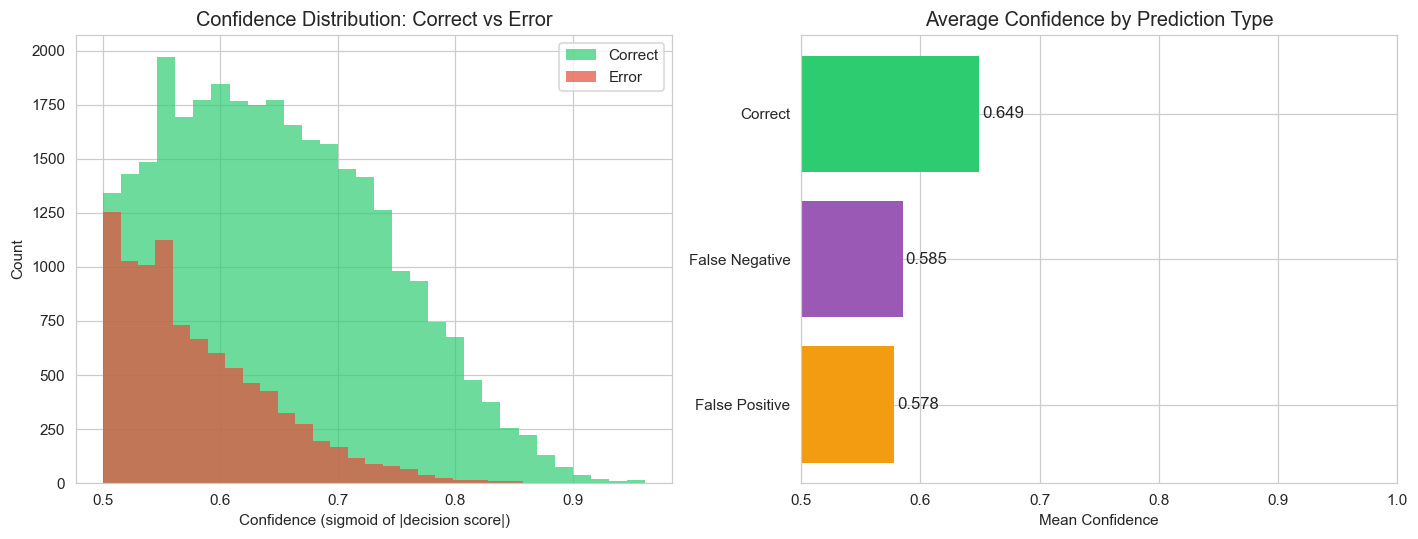

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confidence distribution
test_df[test_df['correct']]['confidence'].hist(
    bins=30, ax=axes[0], alpha=0.7, color=COLOR_POS, label='Correct', edgecolor='none')
test_df[~test_df['correct']]['confidence'].hist(
    bins=30, ax=axes[0], alpha=0.7, color=COLOR_NEG, label='Error', edgecolor='none')
axes[0].set_title('Confidence Distribution: Correct vs Error', fontsize=13)
axes[0].set_xlabel('Confidence (sigmoid of |decision score|)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Mean confidence by error type
conf_summary = test_df.groupby('error_type')['confidence'].mean().sort_values()
colors_map   = {'Correct': COLOR_POS, 'False Positive': COLOR_FP, 'False Negative': COLOR_FN}
bars = axes[1].barh(conf_summary.index, conf_summary.values,
                     color=[colors_map[k] for k in conf_summary.index], edgecolor='none')
axes[1].set_title('Average Confidence by Prediction Type', fontsize=13)
axes[1].set_xlabel('Mean Confidence')
axes[1].set_xlim(0.5, 1.0)
for bar, val in zip(bars, conf_summary.values):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

---
## 8. Conclusions & Model Limitations

### Key Findings

| Finding | Explanation |
|---------|-------------|
| **Negation blindness** | The TF-IDF bag-of-words representation loses word order — "not happy" and "happy" produce similar vectors |
| **Sarcasm failure** | Sarcastic tweets use positive words to express negative sentiment, which tricks the model |
| **Slang ambiguity** | Words like "sick", "fire", "crazy" have both negative and positive meanings depending on context |
| **Short tweets** | Tweets with 1–3 words have the highest error rate — there is not enough signal for the model |
| **High-confidence errors** | Some errors have >90% confidence — the model is systematically wrong, not just uncertain |

### Why We Didn't Reach the 82–84% Benchmark

The published Sentiment140 benchmark uses more sophisticated techniques:
- **Larger vocabulary** (50k+ features vs our 5k)
- **Character n-grams** to capture slang and misspellings
- **Context-aware models** (LSTM, BERT) that understand word order and negation

### Suggested Improvements

1. **Handle negation explicitly** — detect "not", "n't" and flip the sentiment of the following word
2. **Larger TF-IDF vocabulary** — 10k–50k features (Experiment A showed this already helps)
3. **Deep Learning (BERT)** — pre-trained transformers understand context and word order
4. **Emoji features** — the dataset was labeled using emoticons; keeping them as features could help

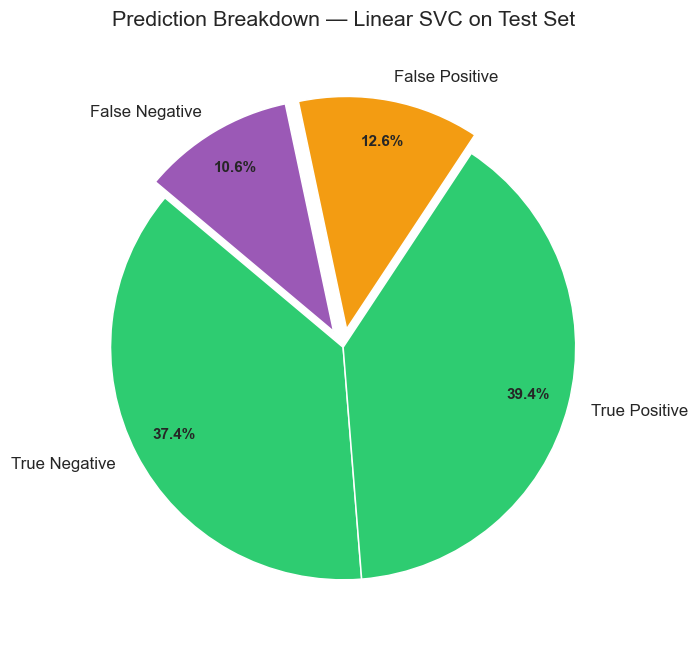


Summary:
  Correct predictions : 30,726 (76.8%)
  Errors              : 9,274 (23.2%)
    False Positives   : 5,048 (12.6%)
    False Negatives   : 4,226 (10.6%)


In [16]:
# Final summary chart
labels  = ['True Negative', 'True Positive', 'False Positive', 'False Negative']
sizes   = [cm[0,0], cm[1,1], cm[0,1], cm[1,0]]
colors  = [COLOR_POS, COLOR_POS, COLOR_FP, COLOR_FN]
explode = [0, 0, 0.08, 0.08]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=140, pctdistance=0.82,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Prediction Breakdown — Linear SVC on Test Set', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(f'\nSummary:')
print(f'  Correct predictions : {cm[0,0]+cm[1,1]:,} ({(cm[0,0]+cm[1,1])/len(test_df)*100:.1f}%)')
print(f'  Errors              : {cm[0,1]+cm[1,0]:,} ({(cm[0,1]+cm[1,0])/len(test_df)*100:.1f}%)')
print(f'    False Positives   : {cm[0,1]:,} ({cm[0,1]/len(test_df)*100:.1f}%)')
print(f'    False Negatives   : {cm[1,0]:,} ({cm[1,0]/len(test_df)*100:.1f}%)')